In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,country,clinical_index
0,28.0,1.0,2.0,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-3.920000
1,29.0,1.0,2.0,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,1,Hungary,-0.670000
2,29.0,1.0,2.0,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-1.947393
3,30.0,0.0,1.0,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0,Hungary,-1.160000
4,31.0,0.0,2.0,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-0.690000


In [15]:
df.shape

(920, 16)

In [16]:
df_clean = df.copy()

In [17]:
df_clean.loc[df_clean["chol"]== 0, "chol"] = np.nan

In [18]:
df_clean.loc[df_clean["trestbps"] == 0, "trestbps"] = np.nan

Data cleaning started by converting clinically impossible values into missing values.

- Cholesterol values equal to 0 were treated as missing because a cholesterol level of zero is physiologically implausible.
- Resting blood pressure values equal to 0 were also treated as missing for the same reason.

These values were converted to NaN to ensure that subsequent imputation methods treat them as missing observations rather than valid measurements.

In [19]:
df_clean.isna().sum()

age                 0
sex                 0
cp                  0
trestbps           60
chol              202
fbs                90
restecg             2
thalach            55
exang              55
oldpeak            62
slope             309
ca                611
thal              486
target              0
country             0
clinical_index     55
dtype: int64

In [20]:
missing_pct = (df_clean.isna().sum() / len(df_clean) * 100).sort_values(ascending=False)
missing_pct

ca                66.413043
thal              52.826087
slope             33.586957
chol              21.956522
fbs                9.782609
oldpeak            6.739130
trestbps           6.521739
thalach            5.978261
exang              5.978261
clinical_index     5.978261
restecg            0.217391
cp                 0.000000
sex                0.000000
age                0.000000
target             0.000000
country            0.000000
dtype: float64

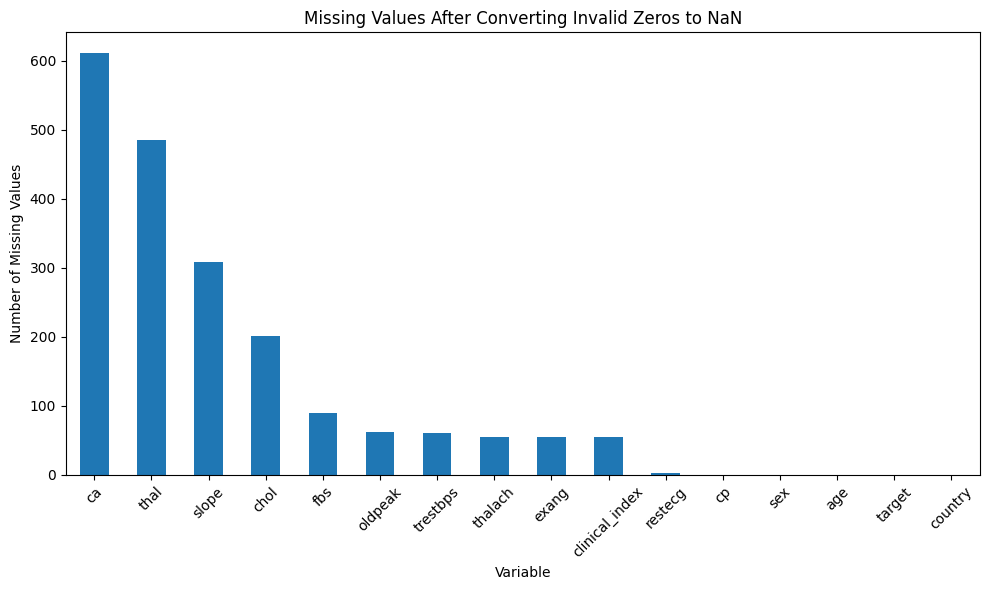

In [21]:
missing_counts = df_clean.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing_counts.plot(kind="bar")

plt.title("Missing Values After Converting Invalid Zeros to NaN")
plt.xlabel("Variable")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Since only two observations (0.22%) contain missing values in restecg, these rows were removed from the dataset. The impact on sample size and class distribution is negligible.

In [22]:
df_clean = df_clean.dropna( subset= ["restecg"])
df_clean.shape

(918, 16)